https://www.kaggle.com/c/bike-sharing-demand/data?select=train.csv

In [164]:
# 바이크 대여량 예측 모델

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import cross_val_score
import seaborn as sns

In [166]:
BSD_DF_train = pd.read_csv('./data/bike-sharing-demand/train.csv')
BSD_DF_train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [167]:
BSD_DF_train.drop(columns=['datetime',]).corr()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
season,1.000000,0.029368,-0.008126,0.008879,0.258689,0.264744,0.190610,-0.147121,0.096758,0.164011,0.163439
holiday,0.029368,1.000000,-0.250491,-0.007074,0.000295,-0.005215,0.001929,0.008409,0.043799,-0.020956,-0.005393
workingday,-0.008126,-0.250491,1.000000,0.033772,0.029966,0.024660,-0.010880,0.013373,-0.319111,0.119460,0.011594
weather,0.008879,-0.007074,0.033772,1.000000,-0.055035,-0.055376,0.406244,0.007261,-0.135918,-0.109340,-0.128655
temp,0.258689,0.000295,0.029966,-0.055035,1.000000,0.984948,-0.064949,-0.017852,0.467097,0.318571,0.394454
atemp,0.264744,-0.005215,0.024660,-0.055376,0.984948,1.000000,-0.043536,-0.057473,0.462067,0.314635,0.389784
humidity,0.190610,0.001929,-0.010880,0.406244,-0.064949,-0.043536,1.000000,-0.318607,-0.348187,-0.265458,-0.317371
windspeed,-0.147121,0.008409,0.013373,0.007261,-0.017852,-0.057473,-0.318607,1.000000,0.092276,0.091052,0.101369
casual,0.096758,0.043799,-0.319111,-0.135918,0.467097,0.462067,-0.348187,0.092276,1.000000,0.497250,0.690414
registered,0.164011,-0.020956,0.119460,-0.109340,0.318571,0.314635,-0.265458,0.091052,0.497250,1.000000,0.970948


In [168]:
BSD_DF_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [169]:
# datetime 계절 변화 반영과 요일반영
# datetime을 datetime 타입으로 변환
BSD_DF_train['datetime'] = pd.to_datetime(BSD_DF_train['datetime'])

# 월과 요일 추출
BSD_DF_train['month'] = BSD_DF_train['datetime'].dt.month
BSD_DF_train['weekday'] = BSD_DF_train['datetime'].dt.weekday  # 0=월요일, 6=일요일

# 월을 사이클릭 피처로 변환 (계절성 반영)
BSD_DF_train['month_sin'] = np.sin(2 * np.pi * BSD_DF_train['month'] / 12)
BSD_DF_train['month_cos'] = np.cos(2 * np.pi * BSD_DF_train['month'] / 12)

# 요일을 One-Hot Encoding
weekday_dummies = pd.get_dummies(BSD_DF_train['weekday'], prefix='weekday')

# 원본 데이터에 붙이기
BSD_DF_train = pd.concat([BSD_DF_train, weekday_dummies], axis=1)

# 필요 없으면 원본 컬럼 삭제
BSD_DF_train = BSD_DF_train.drop(['datetime', 'month', 'weekday'], axis=1)

# 결과 확인
print(BSD_DF_train.head())



   season  holiday  workingday  weather  temp   atemp  humidity  windspeed  \
0       1        0           0        1  9.84  14.395        81        0.0   
1       1        0           0        1  9.02  13.635        80        0.0   
2       1        0           0        1  9.02  13.635        80        0.0   
3       1        0           0        1  9.84  14.395        75        0.0   
4       1        0           0        1  9.84  14.395        75        0.0   

   casual  registered  count  month_sin  month_cos  weekday_0  weekday_1  \
0       3          13     16        0.5   0.866025      False      False   
1       8          32     40        0.5   0.866025      False      False   
2       5          27     32        0.5   0.866025      False      False   
3       3          10     13        0.5   0.866025      False      False   
4       0           1      1        0.5   0.866025      False      False   

   weekday_2  weekday_3  weekday_4  weekday_5  weekday_6  
0      False   

In [170]:
# 필요 없는 컬럼 제거
BSD_DF_train = BSD_DF_train.drop([ 'casual', 'registered'], axis=1)

In [171]:
weekday_cols = [f'weekday_{i}' for i in range(7)]
BSD_DF_train[weekday_cols] = BSD_DF_train[weekday_cols].astype(int)


In [172]:
BSD_DF_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      10886 non-null  int64  
 1   holiday     10886 non-null  int64  
 2   workingday  10886 non-null  int64  
 3   weather     10886 non-null  int64  
 4   temp        10886 non-null  float64
 5   atemp       10886 non-null  float64
 6   humidity    10886 non-null  int64  
 7   windspeed   10886 non-null  float64
 8   count       10886 non-null  int64  
 9   month_sin   10886 non-null  float64
 10  month_cos   10886 non-null  float64
 11  weekday_0   10886 non-null  int64  
 12  weekday_1   10886 non-null  int64  
 13  weekday_2   10886 non-null  int64  
 14  weekday_3   10886 non-null  int64  
 15  weekday_4   10886 non-null  int64  
 16  weekday_5   10886 non-null  int64  
 17  weekday_6   10886 non-null  int64  
dtypes: float64(5), int64(13)
memory usage: 1.5 MB


In [173]:
print(BSD_DF_train['weather'].value_counts().sort_index())



weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64


In [174]:
# weather == 4 제거 (악천후) -샘플이 1개밖에 없어 이상치로 간주
BSD_DF_train = BSD_DF_train[BSD_DF_train['weather'] != 4]

In [175]:
# weather 범주형 변수 - One-Hot Encoding
BSD_DF_train = pd.get_dummies(BSD_DF_train, columns=['weather'], prefix='weather')

In [176]:
BSD_DF_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10885 entries, 0 to 10885
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      10885 non-null  int64  
 1   holiday     10885 non-null  int64  
 2   workingday  10885 non-null  int64  
 3   temp        10885 non-null  float64
 4   atemp       10885 non-null  float64
 5   humidity    10885 non-null  int64  
 6   windspeed   10885 non-null  float64
 7   count       10885 non-null  int64  
 8   month_sin   10885 non-null  float64
 9   month_cos   10885 non-null  float64
 10  weekday_0   10885 non-null  int64  
 11  weekday_1   10885 non-null  int64  
 12  weekday_2   10885 non-null  int64  
 13  weekday_3   10885 non-null  int64  
 14  weekday_4   10885 non-null  int64  
 15  weekday_5   10885 non-null  int64  
 16  weekday_6   10885 non-null  int64  
 17  weather_1   10885 non-null  bool   
 18  weather_2   10885 non-null  bool   
 19  weather_3   10885 non-null  bo

In [177]:
print(BSD_DF_train['season'].value_counts().sort_index())


season
1    2685
2    2733
3    2733
4    2734
Name: count, dtype: int64


In [178]:
# season 범주형 변수 - One-Hot Encoding
BSD_DF_train = pd.get_dummies(BSD_DF_train, columns=['season'], prefix='season')

In [179]:
BSD_DF_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10885 entries, 0 to 10885
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   holiday     10885 non-null  int64  
 1   workingday  10885 non-null  int64  
 2   temp        10885 non-null  float64
 3   atemp       10885 non-null  float64
 4   humidity    10885 non-null  int64  
 5   windspeed   10885 non-null  float64
 6   count       10885 non-null  int64  
 7   month_sin   10885 non-null  float64
 8   month_cos   10885 non-null  float64
 9   weekday_0   10885 non-null  int64  
 10  weekday_1   10885 non-null  int64  
 11  weekday_2   10885 non-null  int64  
 12  weekday_3   10885 non-null  int64  
 13  weekday_4   10885 non-null  int64  
 14  weekday_5   10885 non-null  int64  
 15  weekday_6   10885 non-null  int64  
 16  weather_1   10885 non-null  bool   
 17  weather_2   10885 non-null  bool   
 18  weather_3   10885 non-null  bool   
 19  season_1    10885 non-null  bo

In [180]:
BSD_DF_train = BSD_DF_train.drop(columns=['atemp'])

In [181]:
BSD_DF_train = BSD_DF_train.drop(columns=['month_sin', 'month_cos'])


In [182]:
bool_cols = ['weather_1', 'weather_2', 'weather_3', 'season_1', 'season_2', 'season_3', 'season_4']
BSD_DF_train[bool_cols] = BSD_DF_train[bool_cols].astype(int)


In [183]:
BSD_DF_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10885 entries, 0 to 10885
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   holiday     10885 non-null  int64  
 1   workingday  10885 non-null  int64  
 2   temp        10885 non-null  float64
 3   humidity    10885 non-null  int64  
 4   windspeed   10885 non-null  float64
 5   count       10885 non-null  int64  
 6   weekday_0   10885 non-null  int64  
 7   weekday_1   10885 non-null  int64  
 8   weekday_2   10885 non-null  int64  
 9   weekday_3   10885 non-null  int64  
 10  weekday_4   10885 non-null  int64  
 11  weekday_5   10885 non-null  int64  
 12  weekday_6   10885 non-null  int64  
 13  weather_1   10885 non-null  int64  
 14  weather_2   10885 non-null  int64  
 15  weather_3   10885 non-null  int64  
 16  season_1    10885 non-null  int64  
 17  season_2    10885 non-null  int64  
 18  season_3    10885 non-null  int64  
 19  season_4    10885 non-null  in

In [184]:
# 데이터 분리

# 입력 변수 X (count 컬럼 제외)
X = BSD_DF_train.drop(columns=['count'])
# 타겟 변수 y
y = BSD_DF_train['count']

In [185]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10885 entries, 0 to 10885
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   holiday     10885 non-null  int64  
 1   workingday  10885 non-null  int64  
 2   temp        10885 non-null  float64
 3   humidity    10885 non-null  int64  
 4   windspeed   10885 non-null  float64
 5   weekday_0   10885 non-null  int64  
 6   weekday_1   10885 non-null  int64  
 7   weekday_2   10885 non-null  int64  
 8   weekday_3   10885 non-null  int64  
 9   weekday_4   10885 non-null  int64  
 10  weekday_5   10885 non-null  int64  
 11  weekday_6   10885 non-null  int64  
 12  weather_1   10885 non-null  int64  
 13  weather_2   10885 non-null  int64  
 14  weather_3   10885 non-null  int64  
 15  season_1    10885 non-null  int64  
 16  season_2    10885 non-null  int64  
 17  season_3    10885 non-null  int64  
 18  season_4    10885 non-null  int64  
dtypes: float64(2), int64(17)
memor

In [186]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

In [187]:
# 데이터 스케일링
from sklearn.preprocessing import StandardScaler
# 스케일링 대상 컬럼 리스트
scale_cols = ['temp', 'humidity', 'windspeed']

# 학습/테스트 분할 후 가정 (X_train, X_test 이미 존재)
scaler = StandardScaler()

# 학습 데이터 스케일링 fit & transform
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])

# 테스트 데이터 스케일링 transform만
X_test[scale_cols] = scaler.transform(X_test[scale_cols])


In [188]:
# 모델생성
lr_model = LinearRegression()

In [189]:
# 학습
lr_model.fit(X_train, y_train)

LinearRegression()

In [190]:
# 예측
y_pred = lr_model.predict(X_test)

In [191]:
# 평가
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'R2 Score: {r2:.4f}')

MSE: 22842.5514
RMSE: 151.1375
R2 Score: 0.2972


In [192]:
corr = BSD_DF_train[['holiday', 'workingday']].corr()
print(corr)


             holiday  workingday
holiday     1.000000   -0.250486
workingday -0.250486    1.000000


       feature  importance
2         temp    0.289864
3     humidity    0.272842
4    windspeed    0.174313
18    season_4    0.027646
1   workingday    0.023410
7    weekday_2    0.023075
6    weekday_1    0.022927
8    weekday_3    0.022727
9    weekday_4    0.020207
5    weekday_0    0.019990
13   weather_2    0.018792
12   weather_1    0.016006
17    season_3    0.013718
16    season_2    0.013239
11   weekday_6    0.010689
10   weekday_5    0.010083
15    season_1    0.008904
14   weather_3    0.007907
0      holiday    0.003661


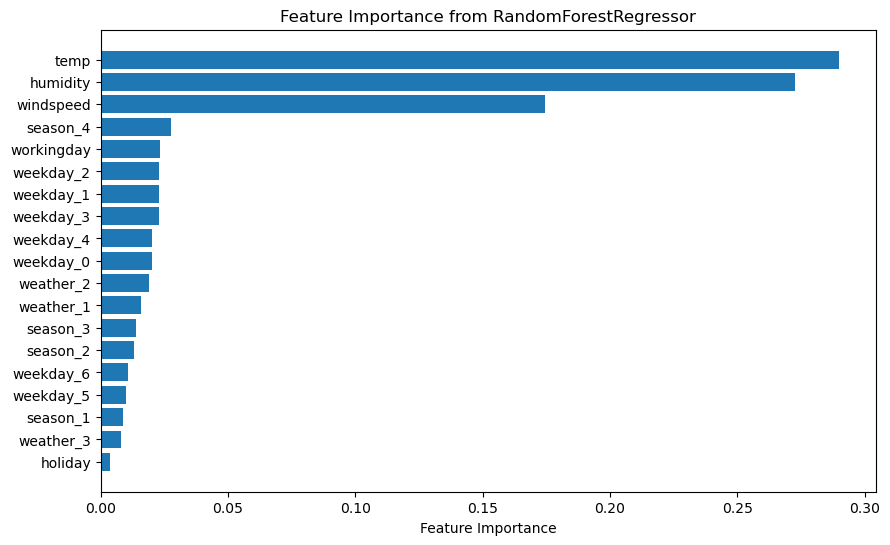

In [193]:
# 데이터 분리 (예시)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 모델 학습
rf = RandomForestRegressor(random_state=14)
rf.fit(X_train, y_train)

# 변수 중요도 추출
importances = rf.feature_importances_
feature_names = X.columns

# 중요도 데이터프레임 생성
feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# 출력
print(feat_imp_df)

# 시각화
plt.figure(figsize=(10,6))
plt.barh(feat_imp_df['feature'], feat_imp_df['importance'])
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance')
plt.title('Feature Importance from RandomForestRegressor')
plt.show()
